In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.8 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/f92esmup/systemic-risk-tax-abm.git

Cloning into 'systemic-risk-tax-abm'...
remote: Enumerating objects: 806, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 806 (delta 55), reused 53 (delta 52), pack-reused 743 (from 1)
Receiving objects: 100% (806/806), 59.21 MiB | 11.77 MiB/s, done.
Resolving deltas: 100% (452/452), done.


In [3]:
!mv systemic-risk-tax-abm/ sys/

In [4]:
import shutil
import os

source_folder = 'sys'
for item in os.listdir(source_folder):
    shutil.move(os.path.join(source_folder, item), os.getcwd())


In [5]:
import glob
import importlib
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from IPython.display import Image, display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.nn import Linear
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from tqdm import tqdm


import figuras
import main

warnings.filterwarnings('ignore')


# SVRAI: Ejecución de la simulación.

In [55]:
#Limpiamos la simulación anterior:
!rm -rf output*/

In [56]:
# Recargar para asegurar que cambios recientes se apliquen si se edita el archivo
importlib.reload(main)

print("--- 1. Ejecutando Simulación (main.py) ---")
try:
    main.run_experiment(simulations_per_mode=1000)
    print("Simulación completada.")
except Exception as e:
    print(f"Ocurrió un error ejecutando la simulación: {e}")

--- 1. Ejecutando Simulación (main.py) ---
--- Configurando Experimento Comparativo (1000 runs/modo) ---
--- Iniciando Ejecución Paralela con 1 procesos ---
--- Total de simulaciones a procesar: 3000 ---


Simulando: 100%|██████████| 3000/3000 [51:09<00:00,  1.02s/sim]

 OK
Simulación completada.


--- 2. Generando Figuras (figuras.py) ---
--- Generando Gráficos Finales ---
Cargando datos...
Generando Fig 3b (DebtRank Profile)...
Generando Fig 3d (Scatter Relative)...
Generando Fig 4 (Distributions)...
Listo. Resultados guardados en ./output_plots

--- Visualización de Resultados Estáticos ---
Mostrando: Fig_3b_DebtRank.png


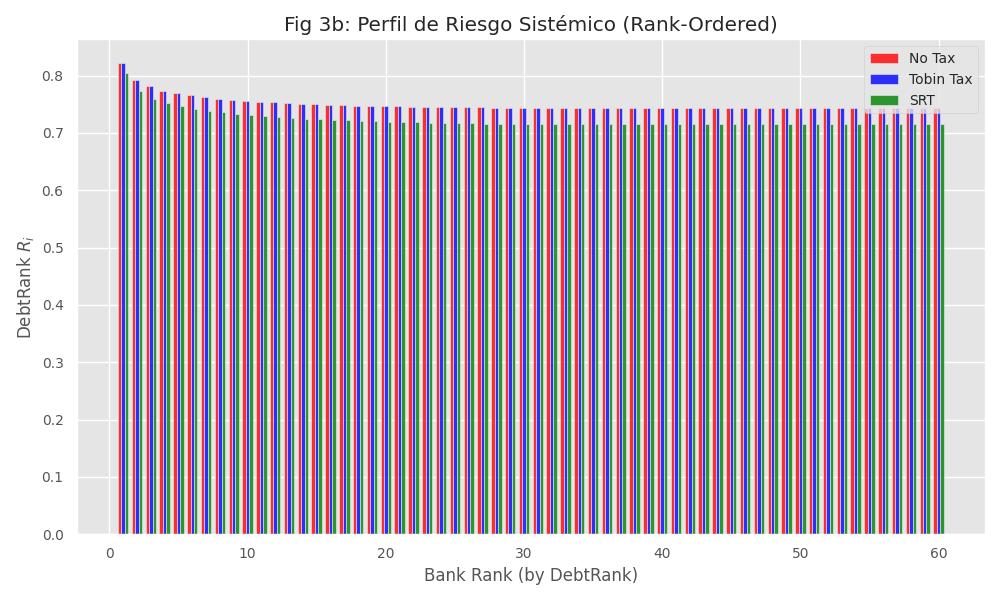

Mostrando: Fig_3d_Scatter.png


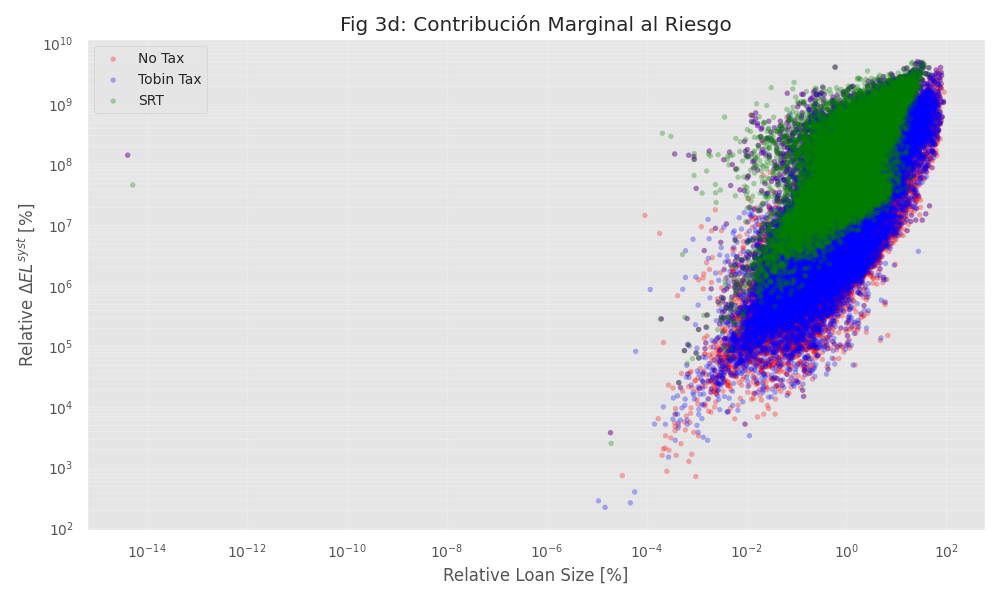

Mostrando: Fig_4a_Losses.png


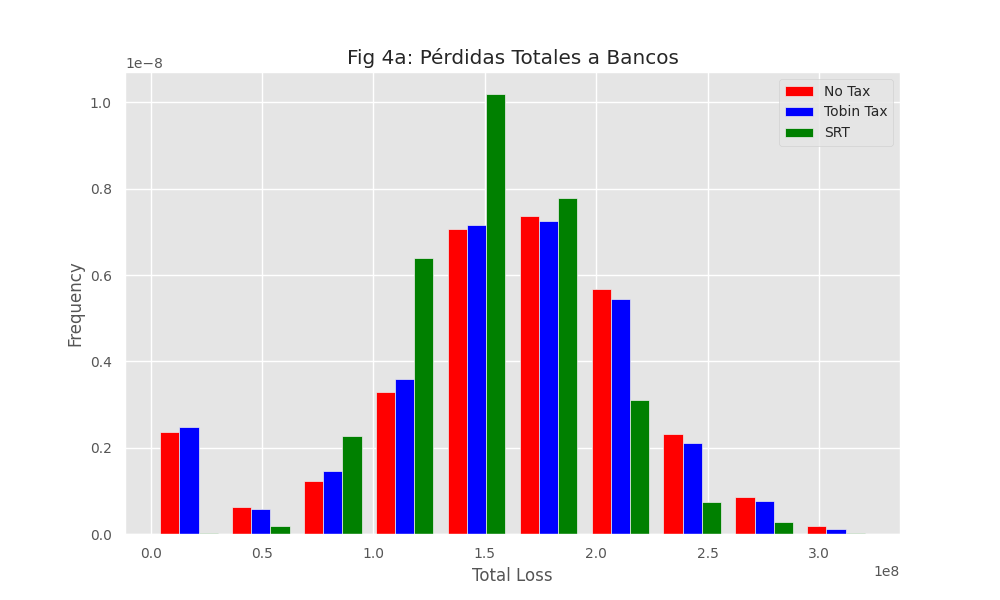

Mostrando: Fig_4b_Cascades.png


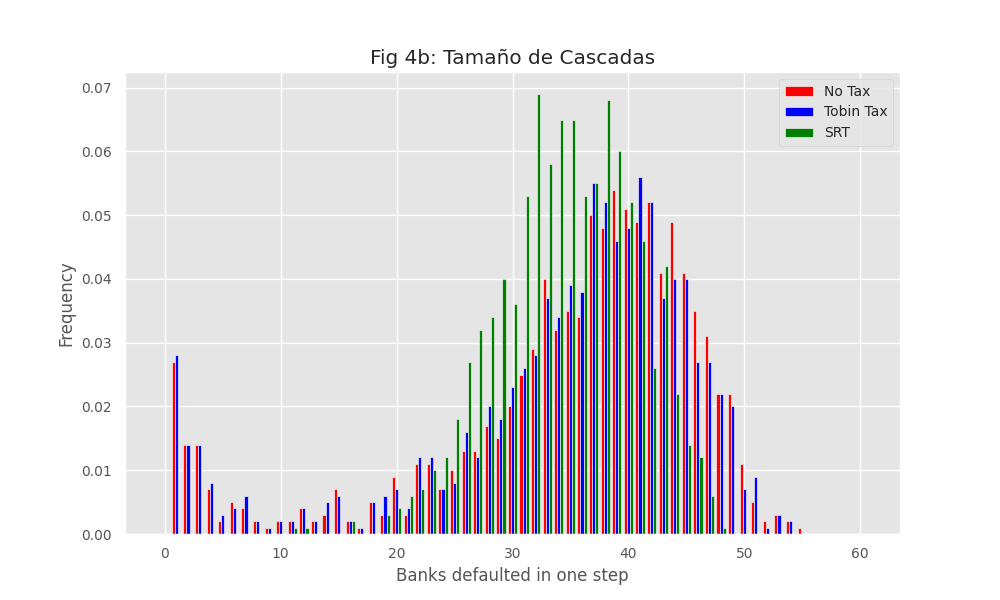

Mostrando: Fig_4c_Volume.png


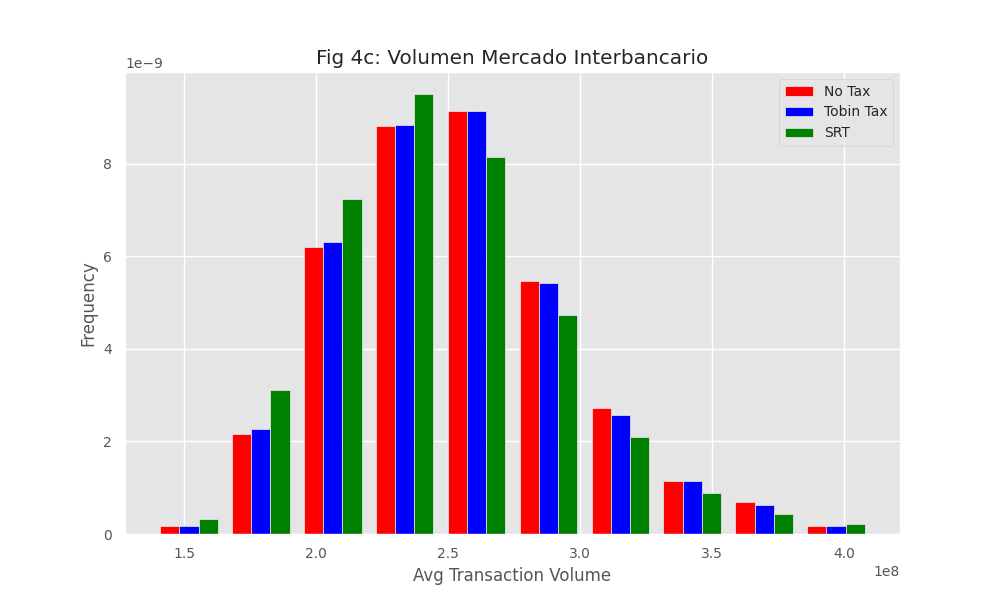

In [57]:

importlib.reload(figuras)

print("--- 2. Generando Figuras (figuras.py) ---")
try:
    # Generar gráficas
    figuras.generar_graficas()

    # Mostrar las figuras generadas
    output_dir = "output_plots"
    if os.path.exists(output_dir):
        pngs = [f for f in os.listdir(output_dir) if f.endswith(".png")]
        print("\n--- Visualización de Resultados Estáticos ---")
        for fig_name in sorted(pngs):
            print(f"Mostrando: {fig_name}")
            display(Image(filename=os.path.join(output_dir, fig_name)))
    else:
        print(f"El directorio {output_dir} no existe.")
except Exception as e:
    print(f"Error generando figuras: {e}")

# TSCD: Financial Regulation Classification Dataset

Este notebook procesa las simulaciones financieras (outputdata) para generar un dataset de grafos (PyTorch Geometric).
El objetivo es clasificar el tipo de regulación (SRT, TOBIN, NINGUNO) basándose en la topología promediada.

## 1. Creación del dataset e ingeniería de características topológicas.

Este cuaderno tiene como objetivo transformar los resultados brutos de las simulaciones del modelo basado en agentes (ABM) en un dataset estructurado compatible con PyTorch Geometric. El proceso consiste en ingerir los archivos parquet generados por cada ejecución, colapsar la dimensión temporal mediante promedios y enriquecer la información financiera con métricas topológicas derivadas de la estructura de la red interbancaria.

El resultado final será una colección de objetos Data (grafos), donde cada nodo (banco) tendrá un vector de características híbrido: tres variables de estado financiero (liquidez, equity, debtrank) y tres métricas de centralidad (clustering, betweenness, eigenvector). Estas estructuras se etiquetarán según el escenario regulatorio (NO_TAX, TOBIN, SRT) y se guardarán en un archivo .pt listo para el entrenamiento de modelos de aprendizaje profundo geométrico.

In [58]:
# Definición de rutas y mapeo de etiquetas
DATA_DIR = "outputdata"
OUTPUT_FILE = "dataset_interbancario.pt"

# Mapeo de clases a enteros para el aprendizaje supervisado
LABEL_MAP = {
    "NINGUNO": 0,  # Se renombrará conceptualmente a NO_TAX
    "TOBIN": 1,
    "SRT": 2
}

print(f"Leyendo datos desde: {DATA_DIR}")

Leyendo datos desde: outputdata


Comenzamos definiendo la lógica de procesamiento para una única simulación. La función principal se encargará de reconstruir el "grafo promedio" de todo el periodo simulado. Para ello, leemos los archivos de bancos y de la red interbancaria sin realizar ningún filtrado temporal, capturando así la dinámica completa desde el inicio hasta el estado estacionario.Primero, agrupamos los datos de los bancos por su identificador para obtener las medias de liquidez, patrimonio y DebtRank. Paralelamente, condensamos la red interbancaria promediando los pesos de las transacciones entre cada par de bancos (origen-destino). Con esta lista de aristas promediada, instanciamos un grafo dirigido en NetworkX, asegurándonos de añadir explícitamente todos los nodos presentes en el dataframe de bancos para no excluir aquellos que pudieran haber quedado aislados (sin conexiones).Una vez construido el grafo, calculamos las métricas topológicas. El coeficiente de clustering, la intermediación (betweenness) y la centralidad de vector propio (eigenvector) se computan para cada nodo y se fusionan con las métricas financieras previamente calculadas. Este paso nos genera una matriz de características completa de dimensiones $(N_{bancos} \times 6)$. Finalmente, convertimos estas estructuras a tensores de PyTorch y empaquetamos todo en un objeto Data, asignándole la etiqueta correspondiente al tipo de impuesto aplicado en esa simulación.

In [59]:
def procesar_simulacion(run_path, label_code):
    """
    Procesa una carpeta de simulación y devuelve un objeto PyTorch Geometric Data.
    """
    try:
        # 1. Carga de datos crudos (sin filtrar tiempo)
        path_banks = os.path.join(run_path, "banks.parquet")
        path_net = os.path.join(run_path, "net_BB.parquet")

        if not (os.path.exists(path_banks) and os.path.exists(path_net)):
            return None

        df_banks = pd.read_parquet(path_banks)
        df_net = pd.read_parquet(path_net)

        # 2. Agregación Temporal (Promedios Globales)
        # Bancos: Media de estados financieros por ID
        # Asumimos columnas: id, liq, eq, dr, t
        bank_features = df_banks.groupby("id")[["liq", "eq", "dr"]].mean().sort_index()
        num_nodes = len(bank_features)

        # Red: Media de pesos de aristas
        edge_means = df_net.groupby(["source", "target"])["weight"].mean().reset_index()

        # 3. Construcción del Grafo con NetworkX para métricas
        G = nx.DiGraph()
        G.add_nodes_from(bank_features.index) # Añadir todos los nodos (incluso aislados)

        # Añadir aristas con peso promedio
        for _, row in edge_means.iterrows():
            G.add_edge(row["source"], row["target"], weight=row["weight"])

        # 4. Cálculo de Métricas Topológicas
        # Clustering (para grafos dirigidos se usa la versión estándar o se convierte, aquí usamos la implementación de nx)
        clustering = nx.clustering(G, weight="weight")

        # Betweenness Centrality (usando pesos si se desea, o puramente estructural)
        betweenness = nx.betweenness_centrality(G, weight="weight")

        # Eigenvector Centrality (manejo de excepciones por convergencia o grafos desconectados)
        try:
            eigenvector = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)
        except:
            # Fallback seguro: centralidad plana o ceros si no converge
            eigenvector = {node: 0.0 for node in G.nodes()}

        # 5. Ensamblaje del Vector de Características (Feature Matrix)
        # Ordenamos las métricas por ID de nodo para alinear con bank_features
        topo_df = pd.DataFrame({
            "clustering": pd.Series(clustering),
            "betweenness": pd.Series(betweenness),
            "eigenvector": pd.Series(eigenvector)
        }).sort_index()

        # Concatenación final: [liq, eq, dr, clust, betw, eigen]
        full_features = pd.concat([bank_features, topo_df], axis=1).fillna(0.0)

        # 6. Creación del Objeto PyTorch Geometric
        x = torch.tensor(full_features.values, dtype=torch.float)

        # Edge Index y Edge Attr
        # Requerimos formato COO (2, num_edges)
        sources = edge_means["source"].values
        targets = edge_means["target"].values
        weights = edge_means["weight"].values

        edge_index = torch.tensor([sources, targets], dtype=torch.long)
        edge_attr = torch.tensor(weights, dtype=torch.float).view(-1, 1)

        y = torch.tensor([label_code], dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

        return data

    except Exception as e:
        print(f"Error procesando {run_path}: {e}")
        return None

Con la lógica encapsulada, procedemos a iterar sobre el sistema de archivos. Buscamos todas las carpetas dentro del directorio de datos que coincidan con el patrón de nomenclatura de nuestras simulaciones. Para cada carpeta encontrada, extraemos el tipo de simulación del nombre del directorio y le asignamos su etiqueta numérica correspondiente utilizando el mapa definido al inicio. Nótese que las carpetas etiquetadas como "NINGUNO" se procesan bajo la etiqueta clase 0 (equivalente a NO_TAX).

Utilizamos una barra de progreso para monitorizar el avance, ya que el cálculo de centralidades (especialmente eigenvector y betweenness) puede ser computacionalmente intensivo si la red es densa o grande. Los grafos resultantes se acumulan en una lista en memoria.

In [60]:
dataset_list = []
sim_folders = glob.glob(os.path.join(DATA_DIR, "run_*"))

print(f"Se encontraron {len(sim_folders)} carpetas de simulación.")

for folder in tqdm(sim_folders, desc="Generando Grafos"):
    folder_name = os.path.basename(folder)

    # Extraer tipo (SRT, TOBIN, NINGUNO)
    # Formato esperado: run_TIPO_sim_NUM
    parts = folder_name.split("_")
    if len(parts) >= 3:
        sim_type = parts[1]

        if sim_type in LABEL_MAP:
            label = LABEL_MAP[sim_type]

            data_obj = procesar_simulacion(folder, label)

            if data_obj is not None:
                dataset_list.append(data_obj)

print(f"\nProcesamiento completado. Total de grafos generados: {len(dataset_list)}")

Se encontraron 3000 carpetas de simulación.


Generando Grafos: 100%|██████████| 3000/3000 [02:50<00:00, 17.58it/s]


Procesamiento completado. Total de grafos generados: 3000


Para finalizar, guardamos la lista completa de objetos geométricos en el archivo .pt especificado. Este archivo contendrá el dataset crudo, preservando la distribución original de los datos para permitir una división adecuada entre entrenamiento y prueba (train/test split) en etapas posteriores, antes de aplicar cualquier técnica de estandarización o normalización. Imprimimos una muestra del primer elemento del dataset para verificar visualmente que las dimensiones de la matriz de características (x), el índice de aristas (edge_index) y la etiqueta (y) son coherentes con lo esperado (N nodos x 6 features).

In [61]:
# Guardar el dataset en disco
torch.save(dataset_list, OUTPUT_FILE)
print(f"Dataset guardado exitosamente en: {OUTPUT_FILE}")

# Inspección rápida del primer elemento
if dataset_list:
    sample = dataset_list[0]
    print("\n--- Inspección de Muestra (Grafo 0) ---")
    print(f"Estructura: {sample}")
    print(f"Dimensiones de Features (x): {sample.x.shape}  [Esperado: (N, 6)]")
    print(f"Etiqueta (y): {sample.y.item()}  [Mapeo: {LABEL_MAP}]")
    print(f"Número de aristas: {sample.num_edges}")
    print("Features (primeras 2 filas):")
    print(sample.x[:2])
else:
    print("Advertencia: La lista de datos está vacía.")

Dataset guardado exitosamente en: dataset_interbancario.pt

--- Inspección de Muestra (Grafo 0) ---
Estructura: Data(x=[60, 6], edge_index=[2, 32], edge_attr=[32, 1], y=[1])
Dimensiones de Features (x): torch.Size([60, 6])  [Esperado: (N, 6)]
Etiqueta (y): 1  [Mapeo: {'NINGUNO': 0, 'TOBIN': 1, 'SRT': 2}]
Número de aristas: 32
Features (primeras 2 filas):
tensor([[ 0.0000e+00, -1.0340e+07,  7.9171e-01,  0.0000e+00,  0.0000e+00,
          1.1628e-06],
        [ 0.0000e+00, -1.4342e+07,  7.9171e-01,  0.0000e+00,  0.0000e+00,
          2.3557e-06]])


## 2. Análisis Exploratorio

Una vez construido el dataset, es crucial inspeccionar las propiedades estadísticas y topológicas de los datos antes de diseñar la arquitectura de la red neuronal. Este análisis nos permitirá:

1. **Validar la separación de clases**: ¿Tienen las simulaciones SRT propiedades distinguibles de las simulaciones NO_TAX o TOBIN?

2. **Detectar colinealidad**: ¿Existe redundancia entre las variables financieras (DebtRank) y las topológicas (Centralidad)?

3. **Determinar hiperparámetros de la GNN**: El diámetro medio de los grafos nos sugerirá la profundidad (número de capas) de la red, mientras que el análisis de varianza (PCA) nos orientará sobre la anchura (dimensión de los canales ocultos).

In [62]:
# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def dataset_to_dataframes(dataset_list):
    """
    Descompone la lista de grafos PyG en dos DataFrames:
    1. df_nodes: Datos a nivel de nodo (para distribuciones y correlaciones).
    2. df_graphs: Datos promedios a nivel de grafo (para PCA y clustering).
    """
    node_rows = []
    graph_rows = []

    # Mapeo inverso para etiquetas
    inv_label_map = {v: k for k, v in LABEL_MAP.items()}

    for i, data in enumerate(dataset_list):
        label_str = inv_label_map[data.y.item()]

        # Extraer matriz de features (convertir tensor a numpy)
        # Columnas: [liq, eq, dr, clust, betw, eigen]
        mat = data.x.numpy()

        # --- Nivel Nodo ---
        for j in range(mat.shape[0]):
            node_rows.append({
                "sim_id": i,
                "label": label_str,
                "liquidity": mat[j, 0],
                "equity": mat[j, 1],
                "debtrank": mat[j, 2],
                "clustering": mat[j, 3],
                "betweenness": mat[j, 4],
                "eigenvector": mat[j, 5]
            })

        # --- Nivel Grafo (Promedios) ---
        # Vector promedio del grafo (Readout simple: Mean Pooling)
        mean_vec = mat.mean(axis=0)
        graph_rows.append({
            "sim_id": i,
            "label": label_str,
            "label_code": data.y.item(),
            "mean_liq": mean_vec[0],
            "mean_eq": mean_vec[1],
            "mean_dr": mean_vec[2],
            "mean_clust": mean_vec[3],
            "mean_betw": mean_vec[4],
            "mean_eigen": mean_vec[5]
        })

    return pd.DataFrame(node_rows), pd.DataFrame(graph_rows)

print("Transformando dataset a DataFrames para análisis...")
if dataset_list:
    df_nodes, df_graphs = dataset_to_dataframes(dataset_list)
    print(f"Hecho. Nodos totales: {len(df_nodes)}, Grafos totales: {len(df_graphs)}")
else:
    print("Error: Dataset vacío.")

Transformando dataset a DataFrames para análisis...
Hecho. Nodos totales: 180000, Grafos totales: 3000


### 2.1. Distribución de Características por Clase
Comenzamos analizando cómo el régimen regulatorio impacta en la estructura interna de la red. Utilizamos Violin Plots para visualizar la densidad de las variables clave.

Betweenness Centrality: Nuestra hipótesis es que el impuesto SRT, al penalizar el riesgo sistémico, debería reducir la presencia de "super-hubs" (bancos centrales por donde pasa todo el flujo), comprimiendo la cola de la distribución.

DebtRank: Esperamos ver diferencias en el riesgo sistémico promedio acumulado bajo cada escenario.

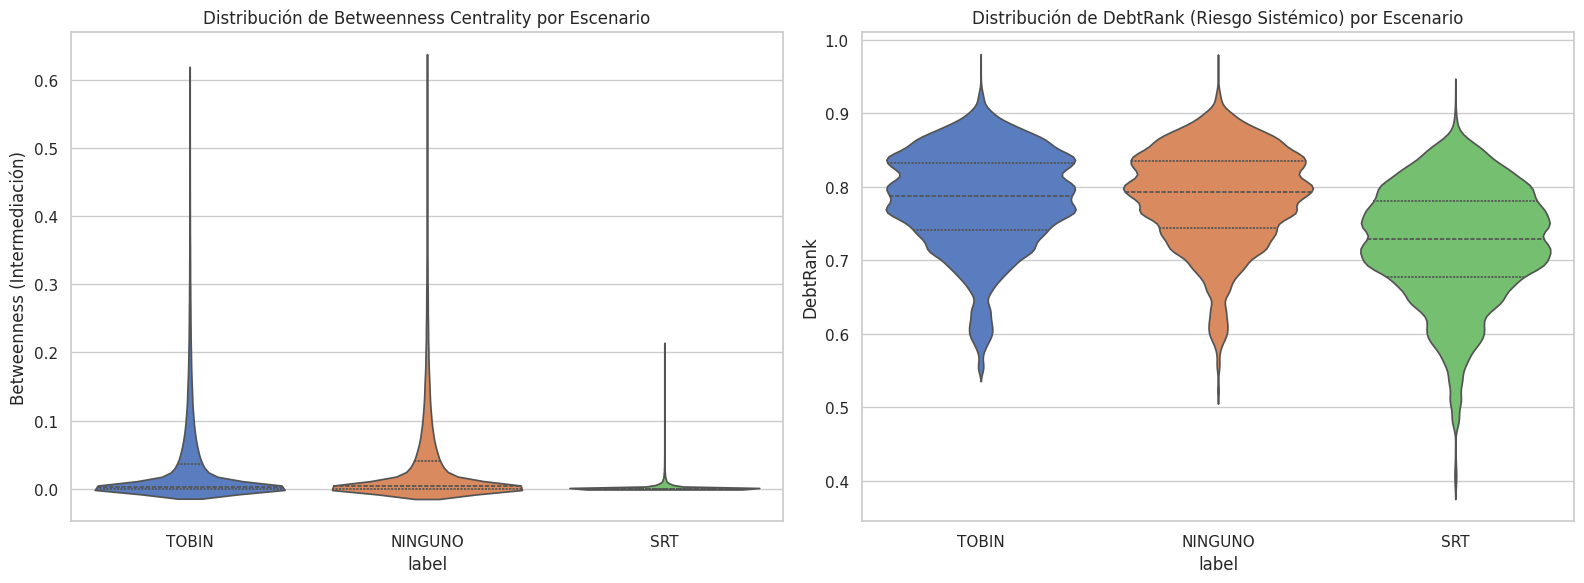

In [63]:
if not df_nodes.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Betweenness
    sns.violinplot(data=df_nodes, x="label", y="betweenness", hue="label",
                   palette="muted", inner="quartile", ax=axes[0], legend=False)
    axes[0].set_title("Distribución de Betweenness Centrality por Escenario")
    axes[0].set_ylabel("Betweenness (Intermediación)")

    # Gráfico 2: DebtRank
    sns.violinplot(data=df_nodes, x="label", y="debtrank", hue="label",
                   palette="muted", inner="quartile", ax=axes[1], legend=False)
    axes[1].set_title("Distribución de DebtRank (Riesgo Sistémico) por Escenario")
    axes[1].set_ylabel("DebtRank")

    plt.tight_layout()
    plt.show()

### 2.2 Análisis de Correlaciones
Generamos un mapa de calor (Heatmap) utilizando la correlación de Spearman (que captura relaciones monótonas no lineales) para entender la redundancia entre nuestras características.

Validación Teórica: ¿Están fuertemente correlacionados DebtRank (métrica financiera de impacto) y Eigenvector Centrality (métrica topológica de influencia)? Una alta correlación validaría que la topología de la red refleja fielmente el riesgo financiero, aunque también sugiere cierta redundancia de información que la red neuronal deberá aprender a gestionar.

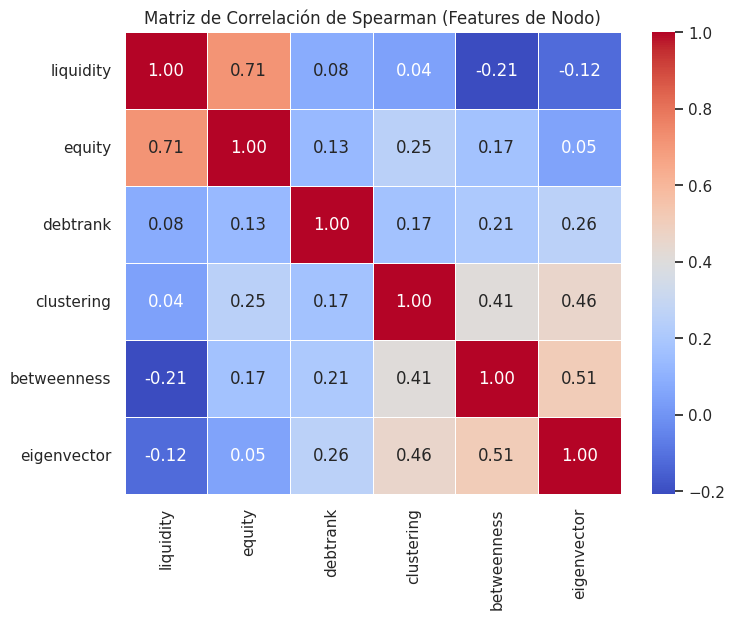

In [64]:
if not df_nodes.empty:
    # Seleccionar solo columnas numéricas de interés
    feature_cols = ["liquidity", "equity", "debtrank", "clustering", "betweenness", "eigenvector"]
    corr_matrix = df_nodes[feature_cols].corr(method="spearman")

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
    plt.title("Matriz de Correlación de Spearman (Features de Nodo)")
    plt.show()

### 2.3. Análisis de Componentes Principales (PCA)
Realizamos un PCA sobre los vectores promedio de cada grafo para proyectar el espacio de simulaciones (dimensión 6) a un plano 2D.

1. Visualización del Espacio de Fases: Si observamos clusters separados por colores (SRT vs NO_TAX), sabremos que las clases son linealmente distinguibles, lo que facilita la tarea de clasificación para la GNN.

2. Varianza Explicada: Este valor es crítico para decidir la "anchura" (hidden_channels) de la red. Si 2 componentes explican el 95% de la varianza, los datos son simples y una red estrecha bastará. Si explican poco (ej. <60%), la información es compleja y necesitaremos más canales ocultos.

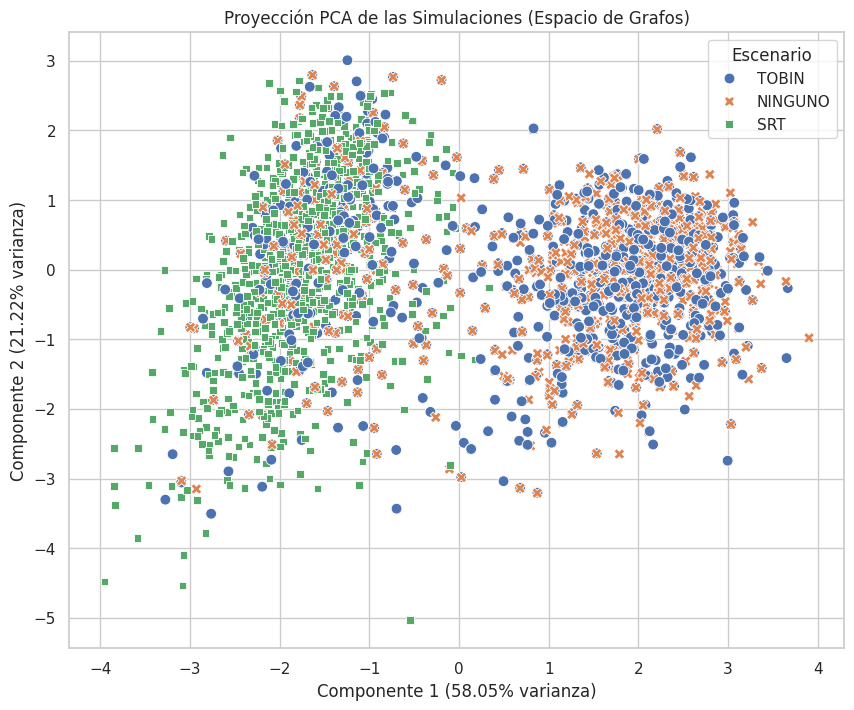

Varianza total explicada por 2 componentes: 79.26%


In [65]:
if not df_graphs.empty:
    # Columnas de features promedio
    mean_cols = [c for c in df_graphs.columns if c.startswith("mean_")]
    X_pca = df_graphs[mean_cols].values
    y_pca = df_graphs["label"].values

    # Estandarizar antes de PCA (crucial para PCA)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_pca)

    # Ejecutar PCA
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)

    # Crear DataFrame temporal para plotear
    df_pca = pd.DataFrame(data=components, columns=["PC1", "PC2"])
    df_pca["Clase"] = y_pca

    # Visualización
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Clase", style="Clase", s=60, palette="deep")
    plt.title("Proyección PCA de las Simulaciones (Espacio de Grafos)")
    plt.xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]:.2%} varianza)")
    plt.ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]:.2%} varianza)")
    plt.legend(title="Escenario")
    plt.show()

    print(f"Varianza total explicada por 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

### 2.4. Análisis Estructural y Recomendación de Arquitectura
Finalmente, calculamos propiedades estructurales globales para dimensionar la profundidad de la GNN (número de capas de paso de mensajes). Dado que los grafos pueden tener nodos desconectados, calculamos el diámetro de la componente conexa más grande (LCC).

Regla de Diseño: El número de capas de una GCN ($L$) determina cuántos "saltos" viaja la información. Idealmente, $L$ debería ser cercano al radio o diámetro efectivo de la red para que un nodo pueda recibir información de todo su vecindario relevante.

In [66]:
def analizar_estructura_grafos(dataset_sample, n_samples=100):
    """Calcula el diámetro promedio de la LCC en una muestra de grafos."""
    diameters = []

    # Tomar una muestra si el dataset es muy grande para no demorar
    samples = dataset_sample[:n_samples] if len(dataset_sample) > n_samples else dataset_sample

    print(f"Calculando métricas estructurales sobre {len(samples)} grafos...")

    for data in tqdm(samples, desc="Métricas Estructurales"):
        # Reconstruir grafo networkx desde edge_index
        G = nx.Graph() # Usamos no dirigido para distancia simple
        G.add_nodes_from(range(data.num_nodes))
        edges = data.edge_index.t().tolist()
        G.add_edges_from(edges)

        # Obtener Componente Conexa Más Grande (LCC)
        if len(G) > 0:
            lcc_nodes = max(nx.connected_components(G), key=len)
            lcc = G.subgraph(lcc_nodes)

            # Calcular diámetro
            try:
                d = nx.diameter(lcc)
                diameters.append(d)
            except:
                pass # Grafos nulos o singulares

    return np.mean(diameters) if diameters else 0

avg_diameter = 0
if dataset_list:
    avg_diameter = analizar_estructura_grafos(dataset_list, n_samples=200)

print(f"\n--- Resultados del Análisis Estructural ---")
print(f"Diámetro Promedio (LCC): {avg_diameter:.2f}")

# Recomendación Heurística
suggested_layers = int(np.ceil(avg_diameter / 2)) + 1
print(f"Recomendación de Profundidad GNN: {suggested_layers} capas (basado en cubrir ~radio medio)")

Calculando métricas estructurales sobre 200 grafos...


Métricas Estructurales: 100%|██████████| 200/200 [00:02<00:00, 83.29it/s]


--- Resultados del Análisis Estructural ---
Diámetro Promedio (LCC): 6.30
Recomendación de Profundidad GNN: 5 capas (basado en cubrir ~radio medio)


Conclusiones del EDA
Con base en las visualizaciones y métricas obtenidas:

Separabilidad: Si el gráfico PCA muestra nubes de puntos bien definidas, confirmamos que las características topológicas y financieras son suficientes para distinguir los escenarios regulatorios.

Arquitectura GCN Sugerida:

Profundidad: Utilizaremos el valor derivado del análisis de diámetro (probablemente entre 3 y 5 capas) para asegurar que el mensaje se propague eficientemente sin sufrir over-smoothing.

Anchura: Si la varianza explicada del PCA es alta (>90%), podemos usar una anchura moderada (ej. 32 o 64 canales). Si es baja, sugeriría una mayor complejidad latente, justificando capas más anchas (128 canales).

El siguiente paso natural será la división del dataset en conjuntos de entrenamiento y prueba, seguido de la normalización de datos para evitar fugas de información.

## 3. Dividir en Train/Test

Llegamos a la etapa crítica de preparación para el aprendizaje automático. Para garantizar que nuestro modelo generalice correctamente y que la evaluación sea honesta, debemos seguir dos reglas de oro:

* **Estratificación:** Dado que podríamos tener un desbalance en las clases (o simplemente por azar en datasets pequeños), forzaremos que la proporción de simulaciones SRT, TOBIN y NO_TAX sea idéntica en los conjuntos de entrenamiento y prueba. Usaremos una división 80/20.

* **Escalado Post-División (Anti-Leakage):** Nunca debemos normalizar todo el dataset antes de dividir. Si lo hiciéramos, la media y desviación típica contendrían información del conjunto de test. Por ello, ajustaremos el escalador (fit) solo usando los nodos de los grafos de entrenamiento y luego aplicaremos esa transformación (transform) a los conjuntos de entrenamiento y prueba.

In [67]:

# 1. Extracción de etiquetas para estratificación
y_all = [data.y.item() for data in dataset_list]

# 2. División Estratificada (80% Train, 20% Test)
train_dataset, test_dataset, y_train, y_test = train_test_split(
    dataset_list, y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=42
)

# 3. Verificación de Proporciones
def print_class_proportions(y_indices, name):
    counts = pd.Series(y_indices).value_counts(normalize=True).sort_index()
    # Mapeo inverso para mostrar nombres
    inv_map = {v: k for k, v in LABEL_MAP.items()}
    counts.index = counts.index.map(inv_map)
    print(f"--- Proporciones en {name} ({len(y_indices)} grafos) ---")
    print(counts.apply(lambda x: f"{x:.2%}"))
    print("")

print_class_proportions(y_train, "TRAIN")
print_class_proportions(y_test, "TEST")

--- Proporciones en TRAIN (2400 grafos) ---
NINGUNO    33.33%
TOBIN      33.33%
SRT        33.33%
Name: proportion, dtype: object

--- Proporciones en TEST (600 grafos) ---
NINGUNO    33.33%
TOBIN      33.33%
SRT        33.33%
Name: proportion, dtype: object



### Estandarización de Características
Procedemos a estandarizar las 6 variables (liquidez, equity, clustering, etc.) para que tengan media 0 y varianza 1. Esto es vital para que la red neuronal converja eficientemente, ya que el Betweenness (rango 0-1) y el Equity (rango miles/millones) tienen escalas muy dispares.

El proceso es:

1. Fit: Extraemos todos los nodos de todos los grafos de Train y calculamos las estadísticas globales.

2. Transform: Aplicamos la resta de la media y la división por la desviación típica a cada nodo individual, tanto en Train como en Test.

In [68]:
# Recolector de todos los features de entrenamiento
train_features_list = [data.x.numpy() for data in train_dataset]
# Concatenar en una gran matriz (N_nodos_total_train x 6)
train_features_flat = np.vstack(train_features_list)

# Ajustar Scaler solo en TRAIN
scaler = StandardScaler()
scaler.fit(train_features_flat)

print("Scaler ajustado sobre nodos de entrenamiento.")
print(f"Medias: {scaler.mean_}")
print(f"Varianzas: {scaler.var_}")

def escalar_dataset(dataset, fitted_scaler):
    """Aplica la transformación a una lista de objetos Data (in-place o copia)."""
    processed_data = []
    for data in dataset:
        # Clonar para no modificar el original en memoria si se re-ejecuta
        d = data.clone()

        # Transformar features
        x_scaled = fitted_scaler.transform(d.x.numpy())
        d.x = torch.tensor(x_scaled, dtype=torch.float)

        processed_data.append(d)
    return processed_data

# Aplicar transformación
train_dataset_scaled = escalar_dataset(train_dataset, scaler)
test_dataset_scaled = escalar_dataset(test_dataset, scaler)

print("Estandarización aplicada a Train y Test.")

Scaler ajustado sobre nodos de entrenamiento.
Medias: [ 1.11774634e+06 -5.70365096e+04  7.62492318e-01  8.09584793e-03
  2.35181343e-02  3.93099199e-02]
Varianzas: [1.49499410e+13 1.29970199e+13 5.79223456e-03 4.95336612e-04
 3.24083935e-03 1.14200079e-02]
Estandarización aplicada a Train y Test.


Guardado Final

Finalmente, persistimos los datasets procesados. Estos archivos .pt son los artefactos finales de este notebook y serán la entrada directa para el  entrenamiento de la GCN.

In [69]:
torch.save(train_dataset_scaled, "train_dataset.pt")
torch.save(test_dataset_scaled, "test_dataset.pt")

print("✅ Pipeline completado.")
print(f"Train guardado: {len(train_dataset_scaled)} grafos -> 'train_dataset.pt'")
print(f"Test guardado:  {len(test_dataset_scaled)} grafos -> 'test_dataset.pt'")

✅ Pipeline completado.
Train guardado: 2400 grafos -> 'train_dataset.pt'
Test guardado:  600 grafos -> 'test_dataset.pt'


## 4. Entrenamiento GCN.

En esta sección construimos el cerebro de nuestro sistema: una Graph Convolutional Network (GCN) basada en la arquitectura de Kipf & Welling.

La red procesará los grafos en lotes de 64 para estabilizar el gradiente.

In [70]:

class GCN(torch.nn.Module):
    def __init__(self):  # Eliminamos el argumento hidden_channels
        super(GCN, self).__init__()
        torch.manual_seed(12345)

        # --- ARQUITECTURA TIPO EMBUDO (Encoder) ---

        # Capa 1: EXPANSIÓN. De 6 features originales a 64 latentes.
        # Captura combinaciones complejas de las variables físicas.
        self.conv1 = GCNConv(6, 64)

        # Capa 2: PROCESAMIENTO. Mantenemos 64 para profundidad.
        self.conv2 = GCNConv(64, 64)

        # Capa 3: PRIMERA REDUCCIÓN. Bajamos a 32.
        self.conv3 = GCNConv(64, 32)

        # Capa 4: REFINAMIENTO. Mantenemos 32.
        self.conv4 = GCNConv(32, 32)

        # Capa 5: COMPRESIÓN FINAL (Embedding). Bajamos a 16.
        # Este será tu vector "resumen" del grafo.
        self.conv5 = GCNConv(32, 16)

        # Clasificador Final: De 16 embeddings a las 3 clases (SRT, TOBIN, NINGUNO)
        self.lin = Linear(16, 3)

    def forward(self, x, edge_index, batch):
        # 1. Entrada -> 64
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        # 2. 64 -> 64
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        # 3. 64 -> 32
        x = self.conv3(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        # 4. 32 -> 32
        x = self.conv4(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        # 5. 32 -> 16 (Embedding Latente)
        x = self.conv5(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        # --- Readout Global ---
        # Obtenemos un vector de 16 números que representa a TODO el grafo
        x = global_mean_pool(x, batch)

        # --- Clasificación ---
        x = self.lin(x)

        return x

print("Arquitectura GCN definida: 6 -> 64 -> 64 -> 32 -> 32 -> 16 -> 3")

Arquitectura GCN definida: 6 -> 64 -> 64 -> 32 -> 32 -> 16 -> 3


Configuración del Entrenamiento
Preparamos los DataLoader para alimentar la GPU de manera eficiente.

* Batch Size: 64 grafos.

* Optimizador: Adam (Learning Rate = 0.01).

* Paciencia: 20 épocas (si en 20 épocas no mejoramos, paramos).

In [71]:
# 1. Carga de Datos por Lotes
train_loader = DataLoader(train_dataset_scaled, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset_scaled, batch_size=128, shuffle=False)

# 2. Inicialización del Modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

print(f"Modelo cargado en: {device}")

Modelo cargado en: cuda


Bucle de Entrenamiento (Training Loop)
Ejecutamos el ciclo de entrenamiento. En cada época:

* Entrenamos con el conjunto de Train y calculamos el gradiente.
* Evaluamos con el conjunto de Test para medir la generalización.
* Registramos las métricas.

In [72]:
def train():
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        total += data.num_graphs
    return total_loss / total, correct / total

def test(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)

            total_loss += loss.item() * data.num_graphs
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
            total += data.num_graphs
    return total_loss / total, correct / total

# --- EJECUCIÓN ---
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
MAX_EPOCHS = 200

print("Iniciando entrenamiento...")

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train()
    test_loss, test_acc = test(test_loader)

    # Guardar métricas
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Test Acc: {test_acc:.4f}')

print("Entrenamiento finalizado.")

Iniciando entrenamiento...
Epoch: 010, Train Loss: 0.7923, Test Acc: 0.5917
Epoch: 020, Train Loss: 0.7673, Test Acc: 0.5633
Epoch: 030, Train Loss: 0.7635, Test Acc: 0.5567
Epoch: 040, Train Loss: 0.7669, Test Acc: 0.5633
Epoch: 050, Train Loss: 0.7659, Test Acc: 0.5600
Epoch: 060, Train Loss: 0.7673, Test Acc: 0.5917
Epoch: 070, Train Loss: 0.7661, Test Acc: 0.5850
Epoch: 080, Train Loss: 0.7590, Test Acc: 0.5900
Epoch: 090, Train Loss: 0.7597, Test Acc: 0.5633
Epoch: 100, Train Loss: 0.7616, Test Acc: 0.5917
Epoch: 110, Train Loss: 0.7611, Test Acc: 0.5567
Epoch: 120, Train Loss: 0.7682, Test Acc: 0.5533
Epoch: 130, Train Loss: 0.7668, Test Acc: 0.5933
Epoch: 140, Train Loss: 0.7573, Test Acc: 0.5917
Epoch: 150, Train Loss: 0.7498, Test Acc: 0.5633
Epoch: 160, Train Loss: 0.7501, Test Acc: 0.5717
Epoch: 170, Train Loss: 0.7589, Test Acc: 0.5550
Epoch: 180, Train Loss: 0.7624, Test Acc: 0.5883
Epoch: 190, Train Loss: 0.7571, Test Acc: 0.5917
Epoch: 200, Train Loss: 0.7509, Test Acc: 

Visualización de Resultados
Finalmente, graficamos las curvas de aprendizaje.

* Curva de Pérdida (Loss): Buscamos que ambas líneas (azul y naranja) desciendan y converjan. Si la naranja (Test) empieza a subir mientras la azul (Train) baja, es señal de overfitting.

* Curva de Precisión (Accuracy): Nos muestra qué tan bueno es el modelo clasificando el régimen regulatorio.

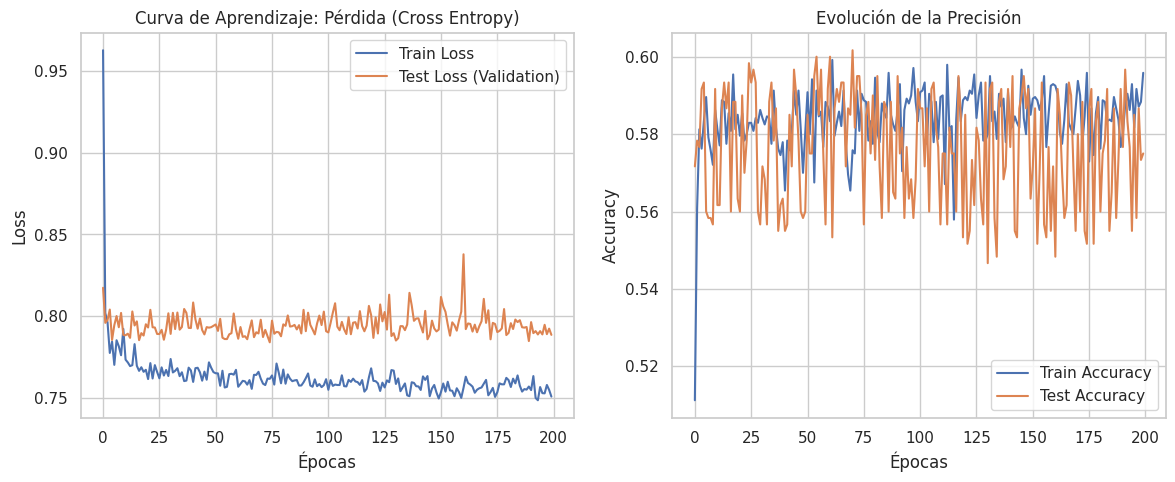

Precisión Final en Test (Mejor Modelo): 60.17%


In [73]:

plt.figure(figsize=(14, 5))

# Gráfica 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss (Validation)')
plt.title('Curva de Aprendizaje: Pérdida (Cross Entropy)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfica 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['test_acc'], label='Test Accuracy')
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

print(f"Precisión Final en Test (Mejor Modelo): {max(history['test_acc']):.2%}")

## 5. Evaluación del Modelo

Una vez entrenada la red, debemos someterla a un examen final utilizando el conjunto de prueba (test_loader), el cual la red nunca ha visto durante el entrenamiento.

No nos conformaremos con la precisión global (Accuracy). Para entender el comportamiento del modelo, calcularemos el Reporte de Clasificación, que nos desglosa la precisión (qué porcentaje de lo predicho como SRT era realmente SRT) y el recall (qué porcentaje de los SRT reales detectó el modelo) para cada clase. Esto es vital para saber si nuestra GCN es sesgada hacia algún régimen regulatorio.

In [74]:
def evaluar_modelo(loader):
    model.eval()
    all_preds = []
    all_labels = []

    # Desactivar cálculo de gradientes para inferencia
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            preds = out.argmax(dim=1)

            # Acumular resultados en CPU
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())

    return all_labels, all_preds

# Ejecutar inferencia en Test
y_true, y_pred = evaluar_modelo(test_loader)

# Nombres de etiquetas para el reporte (asegurando el orden correcto 0,1,2)
target_names = [k for k, v in sorted(LABEL_MAP.items(), key=lambda item: item[1])]

# Métricas Numéricas
acc = accuracy_score(y_true, y_pred)
print(f"--- Precisión Global (Test Accuracy): {acc:.2%} ---\n")

print("--- Reporte de Clasificación Detallado ---")
print(classification_report(y_true, y_pred, target_names=target_names))

--- Precisión Global (Test Accuracy): 57.50% ---

--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

     NINGUNO       0.52      0.60      0.56       200
       TOBIN       0.43      0.17      0.25       200
         SRT       0.66      0.94      0.78       200

    accuracy                           0.57       600
   macro avg       0.54      0.58      0.53       600
weighted avg       0.54      0.57      0.53       600



**Matriz de Confusión**
La matriz de confusión es la herramienta de diagnóstico más potente visualmente. En el eje X tendremos lo que la red predijo y en el eje Y la realidad.

* Diagonal Principal: Aciertos correctos. Queremos que los colores más intensos estén aquí.

* Fuera de la Diagonal: Errores. Por ejemplo, si vemos muchos casos en la intersección (Real: SRT, Predicho: NINGUNO), significaría que el impuesto SRT a veces es tan sutil que la red no lo distingue de un escenario sin impuestos, lo cual tendría implicaciones teóricas interesantes sobre la eficacia de la medida en ciertas simulaciones.

## 6. Análisis del Espacio Latente (Embeddings)

Más allá de la clasificación final, evaluamos la calidad de la representación vectorial (embeddings) que la GCN ha aprendido. Extraemos los vectores de 64 dimensiones de la capa oculta (antes de la clasificación) y los proyectamos en 2D.

**Objetivo:** Verificar si la red neuronal ha logrado separar topológicamente los regímenes regulatorios (SRT, TOBIN, NINGUNO) en clusters definidos, lo cual indicaría un aprendizaje estructural robusto.

In [75]:

def extraer_embeddings(loader, model, device):
    """
    Extrae el vector latente de 16 dimensiones (bottleneck)
    pasando por las 5 capas de la arquitectura 'Embudo'.
    """
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            # --- REPLICAR EL FORWARD PASS EXACTO ---

            # 1. Expansión (Entrada -> 64)
            x = model.conv1(data.x, data.edge_index)
            x = x.relu()

            # 2. Procesamiento (64 -> 64)
            x = model.conv2(x, data.edge_index)
            x = x.relu()

            # 3. Reducción 1 (64 -> 32)
            x = model.conv3(x, data.edge_index)
            x = x.relu()

            # 4. Refinamiento (32 -> 32)
            x = model.conv4(x, data.edge_index)
            x = x.relu()

            # 5. Compresión Final (32 -> 16)
            # AQUÍ es donde obtenemos la representación más pura
            x = model.conv5(x, data.edge_index)
            x = x.relu()

            # --- GLOBAL MEAN POOLING ---
            # Convertimos los nodos (N x 16) en un vector por grafo (1 x 16)
            embedding = global_mean_pool(x, data.batch)

            # Guardamos
            embeddings.append(embedding.cpu().numpy())
            labels.append(data.y.cpu().numpy())

    return np.vstack(embeddings), np.hstack(labels)

Extrayendo embeddings del conjunto de prueba...
Dimensiones obtenidas: (600, 64) (N_grafos x 64 features)


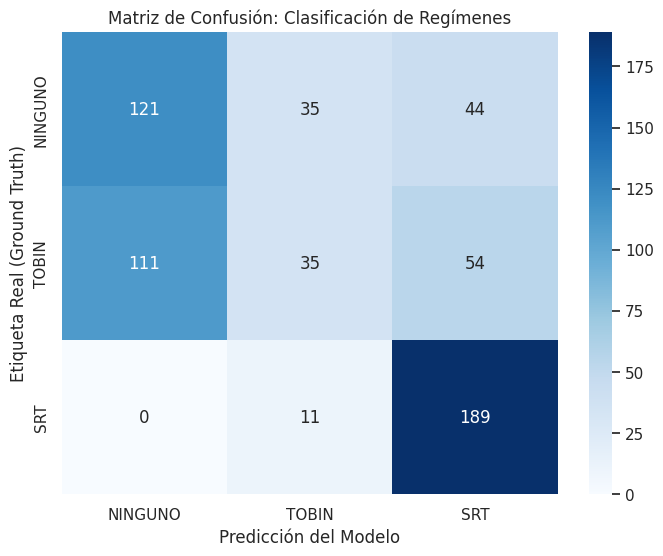

In [76]:
# Calcular matriz
cm = confusion_matrix(y_true, y_pred)

# Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real (Ground Truth)')
plt.title('Matriz de Confusión: Clasificación de Regímenes')
plt.show()

Calculando proyección t-SNE (64D -> 2D)...
Usando perplexity=30 para 600 muestras.


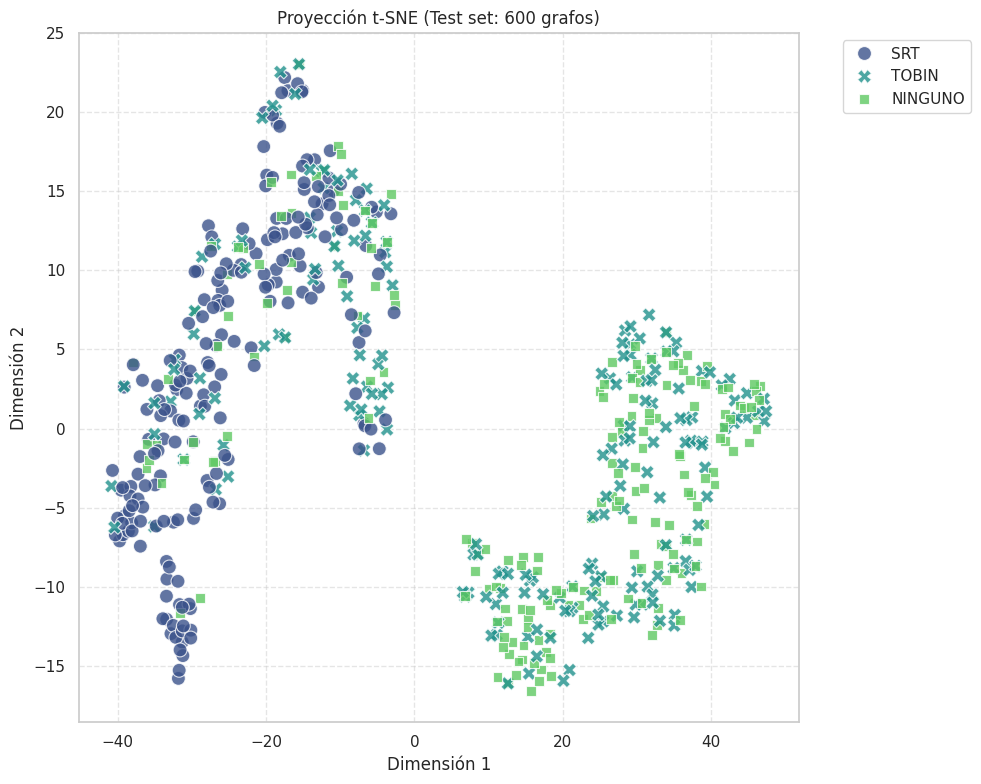

In [77]:
# --- Visualización con t-SNE Corregida ---
print("Calculando proyección t-SNE (64D -> 2D)...")

# Obtenemos el número de muestras en test
n_samples = X_latente.shape[0]

# Ajuste dinámico: La perplejidad debe ser menor que n_samples
# Usamos 30 por defecto, o (n_samples - 1) si son pocos datos
perplexity_val = min(30, n_samples - 1)

if n_samples < 2:
    print("Error: No hay suficientes datos en el conjunto de test para t-SNE.")
else:
    print(f"Usando perplexity={perplexity_val} para {n_samples} muestras.")

    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_val, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X_latente)

    # Crear DataFrame para Seaborn
    df_tsne = pd.DataFrame(X_embedded, columns=['Dim1', 'Dim2'])
    # Mapear códigos numéricos a nombres reales
    nombres_clases = [target_names[i] for i in y_latente]
    df_tsne['Regulación'] = nombres_clases

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=df_tsne, x='Dim1', y='Dim2',
        hue='Regulación', style='Regulación',
        palette='viridis', s=100, alpha=0.8
    )

    plt.title(f"Proyección t-SNE (Test set: {n_samples} grafos)")
    plt.xlabel("Dimensión 1")
    plt.ylabel("Dimensión 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [78]:
# --- Evaluación Cuantitativa del Clustering ---
sil_score = silhouette_score(X_latente, y_latente)

print(f"--- Métrica de Calidad del Espacio Latente ---")
print(f"Silhouette Score: {sil_score:.4f}")
print("-" * 30)
print("Interpretación:")
print(" > 0.5: Estructura de clusters densa y bien separada (Excelente).")
print(" 0.2 - 0.5: Estructura visible pero con cierta superposición (Bueno).")
print(" < 0.2: Superposición significativa, difícil distinción estructural.")

--- Métrica de Calidad del Espacio Latente ---
Silhouette Score: 0.0980
------------------------------
Interpretación:
 > 0.5: Estructura de clusters densa y bien separada (Excelente).
 0.2 - 0.5: Estructura visible pero con cierta superposición (Bueno).
 < 0.2: Superposición significativa, difícil distinción estructural.


Si el Silhouette Score es bajo (<0.2) pero el Accuracy es alto, indicaría que el clasificador final (la capa lineal) está haciendo todo el trabajo pesado, pero que la representación interna no es ideal. Si ambos son altos, tu modelo es robusto.